<a href="https://colab.research.google.com/github/Serge3leo/temp-cola/blob/main/valq/260325/ecosw_sin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from math import *
import locale
import os
import sys
import time

import astropy.time as at
import numpy as np
import scipy
import matplotlib.pyplot as plt
import tqdm

# %matplotlib osx
%config InlineBackend.figure_format = "retina"

In [2]:
locale.setlocale(locale.LC_ALL, 'ru_RU.UTF-8')
time.strftime("%x %X", time.localtime())

'04.04.2026 05:00:42'

In [3]:
# Хм, а скопировать что-ли? Пока, ячейка с `lss_error` на colab 
# работать не будет, надо будет пропускать руками
hdr_add_modules = os.environ['HOME'] + '/soft/valq/modules'

if hdr_add_modules not in sys.path:
    assert 'hdr_save_sys_path' not in globals(), \
            "hdr_add_modules нельзя удалять из sys.path"
    hdr_save_sys_path = sys.path.copy()
    sys.path.insert(1, hdr_add_modules)
elif hdr_add_modules in sys.path:
    print('hdr_add_modules уже есть в sys.path')
else:
    assert False, "Ошибка, однако"

In [4]:
import lss_error
# np.int = np.int64  # dfogn workaround
# lss_error.do_test()  # verbose=True)

# Входные данные

In [5]:
a_ecw = 0
a_ecw_sigma = 1
a_jdh = 2
a_jdh_sigma = 3

```
 "ecosw""sigmaecosw"   "jdh""sigmajdh"
...
система уравнений : e*cos(w0+(jdh-jdh0)*dw)  c ошибками ecos и jdh
```

In [6]:
"""
27 марта 2026 г., в 11:51, Valentina Kozyreva <valiakozyreva@gmail.com> написал(а):

привет. надыбала из литературы ( сгруппировав близкие по jdh с разбросом) еще несколько точек. Посмотри, это в ДЕЙСТВИТЕЛЬНЫХ решается
<ecosw>
"""
data_set_id = "ecosw 260327"
ecosw_in = np.loadtxt("ecosw.txt", skiprows=1, usecols=(0,1,2,3),
                      max_rows=7)
ecosw = ecosw_in  # [(0,3,4,5,6),:] # Если убрать пару точек, то совсем неубедительно
with np.printoptions(precision=6, suppress=True):
    for el in ecosw:
        print(el, at.Time(el[a_jdh], format='mjd').iso)
jdh0 = ecosw[0, a_jdh]
print(f"{a_ecw, a_jdh, jdh0=}")

[   -0.00061     0.00487 52450.         24.     ] 2002-06-25 00:00:00.000
[    0.00192     0.00308 53900.        470.     ] 2006-06-14 00:00:00.000
[    0.00723     0.00498 56522.        189.     ] 2013-08-18 00:00:00.000
[    0.00566     0.0044  57920.         10.     ] 2017-06-16 00:00:00.000
[    0.00492     0.00092 59011.         15.     ] 2020-06-11 00:00:00.000
[    0.00435     0.00097 59753.         10.     ] 2022-06-23 00:00:00.000
[    0.00479     0.00123 60479.         15.     ] 2024-06-18 00:00:00.000
a_ecw, a_jdh, jdh0=(0, 2, 52450.0)


In [7]:
"""
V1097 Her
1 апр. 2026 г., в 15:17, Valentina Kozyreva <valiakozyreva@gmail.com> написал(а):

Привет. Я там уточнила усреднила , получилось : год , его ошибка, есоs  и ее ошибка, нужны те же самые 3 величины
<ewdw>
"""
data_set_id = "V1097 Her 250401"
ewdw = np.genfromtxt("ewdw.txt", names=True, dtype=np.longdouble)

In [8]:
ecosw = np.empty((len(ewdw['ecoswall']), a_jdh_sigma + 1),
                 dtype=ewdw['ecoswall'].dtype)
ecosw[:, a_ecw] = ewdw['ecoswall']
ecosw[:, a_ecw_sigma] = ewdw['errecow']
ecosw[:, a_jdh] = ewdw['years']
ecosw[:, a_jdh_sigma] = ewdw['eryears']
jdh0 = ecosw[0, a_jdh]
with np.printoptions(precision=6, suppress=True):
    for el in ecosw:
        print(el)
    print(f"jdh0 = {jdh0:f}")

[   0.0058    0.0041 2002.462     0.096 ]
[   0.0063    0.0077 2005.611     0.411 ]
[   0.0103    0.0068 2017.493     0.104 ]
[   0.0138    0.0012 2020.444     0.038 ]
[   0.0127    0.0016 2022.473     0.027 ]
[   0.0133    0.0014 2024.458     0.027 ]
[   0.0115    0.0081 2013.937     0.182 ]
jdh0 = 2002.462000


In [9]:
assert isinstance(jdh0, np.float128) and ecosw.dtype == np.float128

## Чётность `cos`

В виду чётности, при условии $t_i > t_0$, решения
$\cos \omega_0 + (t - t_0)*dw$ и $\cos -\omega_0 - (t - t_0)*dw$ 
совпадают.

Пока лень это как-то лучше формализовать. Пока следим за входными
данными на предмет условия $t_i > t_0$ и фильтруем результат.

В оценке Монте-Карло разбиваем результат на две совокупности.

In [10]:
assert np.all(ecosw[:, a_jdh] >= jdh0)

In [11]:
def ecw_chk_neg(x, ecw_=ecosw[:, a_ecw], jdh_=ecosw[:, a_jdh],
                jdh0_=jdh0, weight_=None):
    return x[x_w0] + (jdh_ - jdh0_)*x[x_dw] >= 0.

# def ecw_not_neg(x, ecw_=ecosw[:, a_ecw], jdh_=ecosw[:, a_jdh],
#                 jdh0_=jdh0, weight_=weight):
#     return np.all(x[x_w0] + (jdh_ - jdh0_)*x[x_dw] >= 0.)

# def ecw_to_pos(x, ecw_=ecosw[:, a_ecw], jdh_=ecosw[:, a_jdh],
#                 jdh0_=jdh0, weight_=weight):
#     if not np.all(x[x_w0] + (jdh_ - jdh0_)*x[x_dw] <= 0.):
#         return x
#     assert np.all(jdh_ - jdh0_ >= 0.)
#     assert not ecw_not_neg(x, ecw_, jdh_, jdh0_, weight_)
#     xp = x.copy()
#     xp[x_w0] = -xp[x_w0]
#     xp[x_dw] = -xp[x_dw]
#     assert ecw_not_neg(xp, ecw_, jdh_, jdh0_, weight_)
#     return xp

## Учёт ошибок входных данных

В данном случае, взвешивание на $1 / \sigma_{e \cos(\omega)}$ даёт
весьма консервативный результат. Типа надёжно, и без всякого
излишнего оптимизма.

In [12]:
# weight = np.ones_like(ecosw[:, a_ecw_sigma])

weight = np.full_like(ecosw[:, a_ecw_sigma],
            np.sqrt(ecosw.shape[0]/np.sum(ecosw[:, a_ecw_sigma]**2)))
weight = 1./ecosw[:, a_ecw_sigma]

weight_txt = "Без весов" if np.all(weight[0] == weight) else "Взвешенное"

# Расчёт невязок и матрицы Якоби

In [13]:
method_id = ('e', 'w0', 'dw')
x_e = 0
x_w0 = 1
x_dw = 2
def ecw_fun_c(x, ecw_=ecosw[:, a_ecw], jdh_=ecosw[:, a_jdh],
              jdh0_=jdh0, weight_=weight):
    return np.float64(
                ((x[x_e]*np.cos(x[x_w0] + (jdh_ - jdh0_)*x[x_dw]))
                - ecw_) * weight_)

def ecw_jac_c(x, ecw_=ecosw[:, a_ecw], jdh_=ecosw[:, a_jdh],
              jdh0_=jdh0, weight_=weight):
    jac = np.empty((ecosw.shape[0], len(x)))
    djdh = jdh_ - jdh0_
    jac[:,0] = np.cos(x[x_w0] + djdh*x[x_dw]) * weight_
    jac[:,1] = -x[x_e]*np.sin(x[x_w0] + djdh*x[x_dw]) * weight_
    jac[:,2] = jac[:,1]*djdh
    return jac

## Обход хреновой сходимости
По-хорошему надо разбираться, какого хрена.

Пока вставил завёл параметр `rcnt`, который к любой оптимизации
добавляет несколько поисков из случайных точек в ограничениях.

Но всё равно остаются неспровоцированные пики. Да и скорость работы
страдает.

Возможно, хорошим обходом является `np.float128` для входных данных
(но это работает только на Intel, да и то не везде).
Возможно точность вычисления `jac/fun` ограничивает сходимость?

In [14]:
x_scale = 'jac'
f_scale = np.sqrt(np.sum((ecosw[:, a_ecw]*weight)**2))  # TODO: weight
def_method = 'dogbox'
if isinstance(jdh0, np.float128) and ecosw.dtype == np.float128:
    rcnt = 6
else:
    rcnt = 10  # 7
print(f"{x_scale, f_scale, rcnt=}")
def rcnt_solsq_1(fun_, x0_, jac_, bounds_, method_, kwargs_):
    r = scipy.optimize.least_squares(fun_, x0_, jac=jac_,
            bounds=bounds_ if method_ != 'lm' else {-np.inf, np.inf},
            method=method_, kwargs=kwargs_,
            x_scale=x_scale, f_scale=f_scale,
            xtol=1e-15, ftol=1e-15, gtol=1e-13)
    if np.any(r.x < bounds_[0]) or np.any(bounds_[1] < r.x):
        assert method_ == 'lm'
        return rcnt_solsq_1(fun_, x0_, jac_, bounds_, def_method, kwargs_)
    return r, method_
def rcnt_solsq(fun_, x0_, jac_, bounds_, method_, kwargs_, rcnt_):
    r0, _method = rcnt_solsq_1(fun_, x0_, jac_, bounds_, method_, kwargs_)
    for _ in range(rcnt_):
        xc = np.random.uniform(low=bounds_[0], high=bounds_[1])
        rc, _method = rcnt_solsq_1(fun_, xc, jac_, bounds_, method_, kwargs_)
        if rc.cost < r0.cost:
            r0 = rc
    return r0

x_scale, f_scale, rcnt=('jac', 17.102179692718456632, 6)


In [15]:
def solsq(x0_, bounds_, use_jac=True, method_=def_method,
          ecw_=ecosw[:, a_ecw], jdh_=ecosw[:, a_jdh], jdh0_=jdh0,
          weight_=weight, rcnt_=0):
    jac = ecw_jac_c if use_jac else '2-point'  # {‘2-point’, ‘3-point’, ‘cs’, callable}, optional
    return rcnt_solsq(fun_=ecw_fun_c, x0_=x0_, jac_=jac,
            bounds_=bounds_, method_=method_,
            kwargs_=dict(ecw_=ecw_, jdh_=jdh_, jdh0_=jdh0_,
                         weight_=weight_),
            rcnt_=rcnt_)

## Вариант замены переменной
$\omega_0 = \omega_0' - \frac{\pi}{2}$

После замены, графики немного ровнее, но это видно только на большом
масштабе. Т.е. результаты, пока, идентичны. Только расчёт немного
шустрее.

После усложнений, как-то не очень помогает.

In [16]:
# method_id = ('e', "w0'", 'dw')
if "w0'" == method_id[x_w0]:
    x_e = 0
    x_w0_s = 1
    x_dw = 2
    def ecw_fun_s(x, ecw_=ecosw[:, a_ecw], jdh_=ecosw[:, a_jdh],
                  jdh0_=jdh0, weight_=weight):
        return np.float64(
                    ((x[x_e]*np.sin(x[x_w0_s] + (jdh_ - jdh0_)*x[x_dw]))
                     - ecw_) * weight_)

    def ecw_jac_s(x, ecw_=ecosw[:, a_ecw], jdh_=ecosw[:, a_jdh],
                  jdh0_=jdh0, weight_=weight):
        jac = np.empty((ecosw.shape[0], len(x)))
        djdh = jdh_ - jdh0_
        jac[:,0] = np.sin(x[x_w0_s] + djdh*x[x_dw]) * weight_
        jac[:,1] = x[x_e]*np.cos(x[x_w0_s] + djdh*x[x_dw]) * weight_
        jac[:,2] = jac[:,1]*djdh
        return jac

In [17]:
if "w0'" == method_id[x_w0]:
    def solsq(x0_, bounds_, use_jac=True, method_=def_method,
              ecw_=ecosw[:, a_ecw], jdh_=ecosw[:, a_jdh], jdh0_=jdh0,
              weight_=weight, rcnt_=0):
        jac = ecw_jac_s if use_jac else '2-point'  # {‘2-point’, ‘3-point’, ‘cs’, callable}, optional
        return rcnt_solsq(fun_=ecw_fun_s, x0_=x0_, jac_=jac,
                bounds_=bounds_, method_=method_,
                kwargs_=dict(ecw_=ecw_, jdh_=jdh_, jdh0_=jdh0_,
                             weight_=weight_),
                rcnt_=rcnt_)

In [18]:
if "w0'" == method_id[1]:
    ecw_fun = ecw_fun_s
    ecw_jac = ecw_jac_s
    add2cos = np.array([0., -np.pi/2., 0.])
else:
    ecw_fun = ecw_fun_c
    ecw_jac = ecw_jac_c
    add2cos = np.zeros(3)

def ecw_cost(x, **kwargs):
    f = ecw_fun(x, **kwargs)
    return np.dot(f, f)/2.

In [19]:
def micro_opt(fun, f0, x0, idx, steps=100):
    fm, xm = f0, x0
    for d in np.inf, -np.inf:
        for s in range(1, steps):
            xt = x0.copy()
            xt[idx] = nextafter(x0[idx], d, steps=s)
            ft = fun(xt)
            if ft < fm:
                fm, xm = ft, xt
    return fm, xm

# Начальная точка
Есть вопросы, но пока так.

In [20]:
x0 = np.array((np.average(ecosw[:, a_ecw]), np.pi/2.-0.001, 0.001))
x0

array([1.05285714e-02, 1.56979633e+00, 1.00000000e-03], dtype=float128)

In [21]:
# minres_a.x, minres_a
# minres_b.x, minres_b

In [22]:
if "ecosw 260327" == data_set_id:
    x0 = np.array([4.99129963e-03, 4.75366679e+00 - 2*pi, 2.54988863e-04])
    print(x0)

In [23]:
if "ecosw 260327" == data_set_id:
    if not np.all(weight[0] == weight):
        x0 = np.array([4.99129963e-03, 0.04127780961530991, 2.54988863e-04])
        x0 = np.array([0.004954477174761145, 0.07688715100396747, 0.017458411894649924])
        x0 = np.array([0.004954477179025791, -6.2062981611627706 + 2*pi, 0.01745841189584378])
        x0 = np.array([0.004954477179025791, 0.07688714601682278, 0.01745841189584378])
        if "w0" == method_id[1]:
            x0[1] += -np.pi/2.
            x0 = np.array([0.0049544771645790645, -1.493909170419644, 0.01745841189261346])
            x0 = np.array([0.00495447715987243, -1.4939091737708958, 0.017458411892398665])
    else:
        x0 = np.array([0.006297200962871222, -0.09100045390164574, 0.00032152156628824065])
        x0 = np.array([0.006297200962871222, -0.09100045390164468, 0.00032152156628824065])
        if "w0" == method_id[1]:
            x0[1] += -np.pi/2.
    print(x0)

In [24]:
if "V1097 Her 250401" == data_set_id:
    if not np.all(weight[0] == weight):
        x0 = np.array([ 0.01403113,  2.74652896, -0.03979614])
        # x0 = np.array([ 0.01403113, 0.418,  0.03979614])
        # x0 = np.array([0.013429551470368973, 0.4180784848465336, 0.06164879182332056])
        # x0 = np.array([0.013429551467315488, 2.7235141655050423, -0.061648791554937486])
        if "w0" == method_id[1]:
            x0[1] += -np.pi/2.
            x0 = np.array([0.013429551467399145, 1.1527178386490784, -0.061648791557917394])
    else:
        x0 = np.array([0.014031132610270426, 1.1757326357358786, -0.039796144156657824])
        x0 = np.array([0.014031132524876427, 1.1757326350774708, -0.03979614485835622])
    print(x0)

[ 0.01342955  1.15271784 -0.06164879]


In [25]:
ecw_chk_neg(x0)

array([ True,  True,  True,  True, False, False,  True])

In [26]:
# Отрицательные можно, но при знакопеременности
assert not np.all(~ecw_chk_neg(x0))

# Границы
Первоначально, поиск не уходил с нуля. Пока оставил ненулевые ограничения.

Ограничение $\omega \in [-2 \pi ... 2 \pi]$ , выбрано таковым, что бы 
поиск не упирался в него.

In [27]:
def norm_w0_ex(a, low, high, period):
    a = np.asarray(a)
    r = a.copy()
    if 1 == r.ndim:
        r = r.reshape(3,1)
    r[x_w0,:] = np.where(r[x_w0,:] > high, r[x_w0,:] - period, r[x_w0,:])
    r[x_w0,:] = np.where(r[x_w0,:] <= low, r[x_w0,:] + period, r[x_w0,:])
    return r.reshape(a.shape)

if "V1097 Her 250401" == data_set_id:
    def norm_w0(a):
        return norm_w0_ex(a, -np.pi/2, 3.*np.pi/2., 2.*np.pi)
else:
    def norm_w0(a):
        return norm_w0_ex(a, -np.pi, np.pi, 2.*np.pi)

np.testing.assert_array_equal(norm_w0([0., 2.*pi, 0.]),
                              [0., 0., 0.])
np.testing.assert_array_equal(norm_w0([[0.], [-2.*pi], [0.]]).T,
                              [[0., 0., 0.]])

In [28]:
bounds = np.array(((1e-7, -2.*np.pi, -0.2),
                   (0.5, 2.*np.pi, 0.2)))
bounds

array([[ 1.00000000e-07, -6.28318531e+00, -2.00000000e-01],
       [ 5.00000000e-01,  6.28318531e+00,  2.00000000e-01]])

# Поиск и сравнение матриц Якоби

In [29]:
res = solsq(x0, bounds, method_='lm')
res

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [-8.476e-02  1.841e-01  4.100e-01 -3.196e-01  4.285e-01
               -1.050e-01  7.653e-02]
           x: [ 1.343e-02  1.153e+00 -6.165e-02]
        cost: 0.2559042714613619
         jac: [[ 9.903e+01 -2.993e+00 -0.000e+00]
               [ 7.463e+01 -1.427e+00 -4.495e+00]
               ...
               [ 6.996e+02  1.937e+00  4.260e+01]
               [ 1.114e+02 -7.141e-01 -8.195e+00]]
        grad: [ 8.438e-13 -2.828e-13  4.186e-12]
  optimality: 4.186317958954078e-12
 active_mask: [0 0 0]
        nfev: 3
        njev: 2

In [30]:
res = solsq(x0, bounds, method_='lm', rcnt_=rcnt)
res

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [-8.476e-02  1.841e-01  4.100e-01 -3.196e-01  4.285e-01
               -1.050e-01  7.653e-02]
           x: [ 1.343e-02  1.153e+00 -6.165e-02]
        cost: 0.2559042714613619
         jac: [[ 9.903e+01 -2.993e+00 -0.000e+00]
               [ 7.463e+01 -1.427e+00 -4.495e+00]
               ...
               [ 6.996e+02  1.937e+00  4.260e+01]
               [ 1.114e+02 -7.141e-01 -8.195e+00]]
        grad: [ 8.438e-13 -2.828e-13  4.186e-12]
  optimality: 4.186317958954078e-12
 active_mask: [0 0 0]
        nfev: 3
        njev: 2

In [31]:
resn = solsq(x0, bounds, use_jac=False, method_='lm')
resn

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [-8.476e-02  1.841e-01  4.100e-01 -3.196e-01  4.285e-01
               -1.050e-01  7.653e-02]
           x: [ 1.343e-02  1.153e+00 -6.165e-02]
        cost: 0.2559042714613619
         jac: [[ 9.903e+01 -2.993e+00  0.000e+00]
               [ 7.463e+01 -1.427e+00 -4.495e+00]
               ...
               [ 6.996e+02  1.937e+00  4.260e+01]
               [ 1.114e+02 -7.141e-01 -8.195e+00]]
        grad: [ 9.062e-08 -2.538e-10 -3.817e-09]
  optimality: 9.062264894055261e-08
 active_mask: [0 0 0]
        nfev: 9
        njev: None

In [32]:
resn = solsq(x0, bounds, use_jac=False, method_='lm', rcnt_=rcnt)
resn

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [-8.476e-02  1.841e-01  4.100e-01 -3.196e-01  4.285e-01
               -1.050e-01  7.653e-02]
           x: [ 1.343e-02  1.153e+00 -6.165e-02]
        cost: 0.2559042714613619
         jac: [[ 9.903e+01 -2.993e+00  0.000e+00]
               [ 7.463e+01 -1.427e+00 -4.495e+00]
               ...
               [ 6.996e+02  1.937e+00  4.260e+01]
               [ 1.114e+02 -7.141e-01 -8.195e+00]]
        grad: [ 9.062e-08 -2.538e-10 -3.817e-09]
  optimality: 9.062264894055261e-08
 active_mask: [0 0 0]
        nfev: 9
        njev: None

In [33]:
(res.x - resn.x)*2./np.abs(res.x + resn.x)

array([-6.14833401e-12,  1.02119290e-11,  1.88935209e-11])

In [34]:
(res.jac - resn.jac)*2./np.abs(res.jac + resn.jac)

/var/folders/wy/z0gbkfgs7mv24ryqkdm90rm40009rh/T/ipykernel_85536/2699449834.py:1: RuntimeWarning: invalid value encountered in divide
  (res.jac - resn.jac)*2./np.abs(res.jac + resn.jac)


array([[-2.64962339e-11, -7.05911855e-12,             nan],
       [-2.19716218e-11, -1.30848095e-11, -6.53056962e-11],
       [-6.72205045e-12, -1.23268317e-10, -1.50207648e-09],
       [-1.44395657e-12, -7.38143460e-10, -2.71042293e-09],
       [ 2.84657806e-12, -4.28824556e-10,  2.00861175e-09],
       [ 7.70908438e-12, -1.79470662e-10,  2.76933097e-09],
       [-1.19977324e-11, -5.47640020e-11, -8.51312068e-10]])

In [35]:
if "w0" != method_id[1]:
    print((resn.jac - ecw_jac_c(resn.x - [0., pi/2, 0.]))
          /ecw_jac_c(resn.x - [0., pi/2, 0.]))

Не похоже, что бы была явная лажа в вычислении матрицы Якоби. Более-менее.

In [36]:
np.cos(resn.x[x_w0] + add2cos[x_w0] + (ecosw[:, a_jdh] - jdh0)*resn.x[x_dw])

array([0.40600519, 0.57467792, 0.97455374, 0.99902558, 0.99672646,
       0.97940382, 0.90248237], dtype=float128)

In [37]:
np.cos(res.x[x_w0] + add2cos[x_w0] + (ecosw[:, a_jdh] - jdh0)*res.x[x_dw])

array([0.40600519, 0.57467792, 0.97455374, 0.99902558, 0.99672646,
       0.97940382, 0.90248237], dtype=float128)

Замечание до замены:
> Три числа около 1 намекают, что стоит попробовать сделать
замену: $\omega_0 = \omega_0' - \frac{\pi}{2}$

Смысл замены так пока и не подтвердился, пока не ясен.

# Типа невязки
Пока выглядит всё более менее.  Однако, решения с весами и без весов
заметно различаются.

Взвешенные невязки, в $\sigma$ каждой точки.

In [38]:
(res.fun / weight) / ecosw[:, a_ecw_sigma]

array([-0.084764  ,  0.18411256,  0.40997347, -0.31961214,  0.4284933 ,
       -0.10503285,  0.07653499], dtype=float128)

In [39]:
ecosw[:, a_jdh_sigma]

array([0.096, 0.411, 0.104, 0.038, 0.027, 0.027, 0.182], dtype=float128)

In [40]:
np.sqrt(np.sum(res.fun**2)), np.sqrt(2.*res.cost)

(0.7154079555908809, 0.7154079555908809)

Невязки без весов, так сказать, а ля натурель.

In [41]:
res.fun/weight

array([-0.00034753,  0.00141767,  0.00278782, -0.00038353,  0.00068559,
       -0.00014705,  0.00061993], dtype=float128)

ecosw 260327:
- При оценке без весов, невязка меньше оценки ошибки в 4,5 раза;
- При взвешенной оценке, невязка меньше оценки ошибки в 2,8 раза
  ($\approx \sqrt7$), что бы это значило?

V1097 Her 250401:
- При оценке без весов, невязка меньше оценки ошибки в 6 раз;
- При взвешенной оценке, невязка меньше оценки ошибки в 4.2 раза.

In [42]:
np.linalg.norm(ecosw[:, a_ecw_sigma])/np.linalg.norm(res.fun/weight)

4.212870525449419691

# Оценка точности решения МНК
По матрице Якоби (статистическая). Статистика, конечно, никакая, да и
минимум неглубокий, в общем, сплошной розовый оптимизм, но... 

In [43]:
err, cov = lss_error.scipyERR(res)
with np.printoptions(precision=5):
    print(err)
    print(cov)
    print(f"{data_set_id}, {method_id[1]}, {weight_txt}")
    for i in range(3):
        print(f"{method_id[i]:4} = {res.x[i]: .5f} ± {err[i]:.5f} (1𝜎, 68%)")
        if "w0'" == method_id[i]:
            print(f"{'w0':4} = {res.x[i] + add2cos[i]: .5f} ± {err[i]:.5f} (1𝜎, 68%)")

[0.00033 0.11179 0.01075]
[[ 1.05730e-07  6.24932e-06 -1.68634e-06]
 [ 6.24932e-06  1.24965e-02 -7.10609e-04]
 [-1.68634e-06 -7.10609e-04  1.15573e-04]]
V1097 Her 250401, w0, Взвешенное
e    =  0.01343 ± 0.00033 (1𝜎, 68%)
w0   =  1.15272 ± 0.11179 (1𝜎, 68%)
dw   = -0.06165 ± 0.01075 (1𝜎, 68%)


```
V1097 Her 250401, w0', Взвешенное
e    =  0.01343 ± 0.00033 (1𝜎, 68%)
w0'  =  0.41808 ± 0.11179 (1𝜎, 68%)
w0   = -1.15272 ± 0.11179 (1𝜎, 68%)
dw   =  0.06165 ± 0.01075 (1𝜎, 68%)
```

```
V1097 Her 250401, w0', Без весов
e    =  0.01403 ± 0.00325 (1𝜎, 68%)
w0'  =  0.39506 ± 0.09939 (1𝜎, 68%)
w0   = -1.17573 ± 0.09939 (1𝜎, 68%)
dw   =  0.03980 ± 0.02318 (1𝜎, 68%)
```

```
V1097 Her 250401, w0, Взвешенное
e    =  0.01343 ± 0.00033 (1𝜎, 68%)
w0   =  1.15272 ± 0.11179 (1𝜎, 68%)
dw   = -0.06165 ± 0.01075 (1𝜎, 68%)
```

# Зависимость суммы квадратов невязок от переменных

Разбиваем область значений каждой переменной на интервалы, и решаем
задачу МНК с ограничением в этом интервале.

Т.е. пытаемся таким образом визуализировать доверительные интервалы.

In [44]:
bound_plot_log = []
def bound_plot(res_, bounds_, log=True):
    global bound_plot_log
    start = time.perf_counter()
    minres = res_
    fig, ax = plt.subplots(3, 3)
    for i in range(3):
        resj = res_
        boundi = bounds_[:, i].copy()
        lowi = np.linspace(boundi[0], boundi[1], num=128)
        costi = np.zeros((len(lowi) - 1,))
        res_xi = np.zeros((len(lowi) - 1, 3))
        if bound_plot_log:
            bound_plot_log.append(dict(
                    method=method_id[i], lowi=lowi,
                    costi=costi, res_xi=res_xi))
        for j in range(len(lowi) - 1):
            xj = res.x.copy()  # TODO ???
            boundj = bounds_.copy()
            for k in range(3):
                assert boundj[0, k] < xj[k] and xj[k] < boundj[1, k], \
                    f"{k, boundj[0, k], xj[k], boundj[1, k]=}"
            boundj[0, i] = lowi[j]
            boundj[1, i] = lowi[j + 1]
            xj[i] = np.average(boundj[:, i])
            for k in range(3):
                assert boundj[0, k] < xj[k] and xj[k] < boundj[1, k], \
                    f"{k, boundj[0, k], xj[k], boundj[1, k]=}"
            resj = solsq(xj, boundj, rcnt_=rcnt)
            costi[j] = resj.cost
            res_xi[j] = resj.x
            if resj.cost < minres.cost:
                minres = resj
        for j in range(1, len(costi) - 1):
            if costi[j] >= 1.1*max(costi[j-1], costi[j+1]):
                print(f"Пик: {i, method_id[i]=}"
                      f" {j, lowi[j], lowi[j]=}"
                      f" {costi[j-1], costi[j], costi[j+1]}")
                boundj[0, i] = lowi[j]
                boundj[1, i] = lowi[j + 1]
                xj[i] = np.average(boundj[:, i])
                resj = solsq(xj, boundj, rcnt_=rcnt*5)
                if resj.cost < 1.1*max(costi[j-1], costi[j+1]):
                    print(f"Исправлен на {resj.cost=}")
                    costi[j] = resj.cost
                    res_xi[j] = resj.x
                    if resj.cost < minres.cost:
                        minres = resj
                else:
                    print(f"Удалён")
                    costi[j] = np.nan
                    res_xi[j,:] = np.nan
        ax[0][i].plot(res_xi[:,i], np.sqrt(2.*costi),
                      label=f"$\\sigma$ of {method_id[i]}")
        if log:
            ax[0][i].set_yscale('log')
        ax[0][i].legend()
        for j in range(3):
            if j != i:
                axji = ax[j + 1 if j < i else j][i]
                axji.plot(res_xi[:,i], res_xi[:,j],
                              label=f"{method_id[j]} of {method_id[i]}")
                axji.legend()
                # axji.set_ylabel(f"{method.id[j]}")
        axji.set_xlabel(f"{method_id[i]}")

    stop = time.perf_counter()
    fig.suptitle(f"{data_set_id}, {method_id[1]}, {weight_txt}"
                 f"\n{time.strftime("%x %X", time.localtime())}"
                 f" ({stop - start:.1f} {rcnt=})")
    return fig, ax, minres

## По всей области значений
Верхний ряд это $\sqrt{\sum{{O-C}^2}}$, в зависимости от
изменения соответствующего параметра.

На графиках нижних двух рядов отображаются найденные значения двух
других параметров (свободных параметров).

ecosw 260327:
1. Эксцентриситет, невязка значительно растёт до $e = 0.055..0.059$,
   однако, после устанавливается на уровне $1.6 \times \sigma$. Т.е.
   решение уравнения, само по себе, не даёт надёжных доказательств,
   что он небольшой.
2. $\omega_0$ определяется хреново;
3. `dw` зависит от остальных параметров.

V1097 Her 250401:
1. Эксцентриситет, более-менее растёт до $e = 0.05$, после
   устанавливается на уровне $1.2\times\sigma$ от столбца ошибок
   входных данных. Что, конечно, вызывает сомнения. Однако, невязка
   в решении в несколько раз меньше столбца ошибок входных данных.
   Непонятно;
2. К $\omega_0$ и `dw` вопросов нет;

Пик: i, method_id[i]=(0, 'e') j, lowi[j], lowi[j]=(21, 0.08267724881889765, 0.08267724881889765) (0.7073085549273831, 323.4589089214412, 0.7079296071144354)
Исправлен на resj.cost=0.7076417872477223
Пик: i, method_id[i]=(0, 'e') j, lowi[j], lowi[j]=(37, 0.14566936220472443, 0.14566936220472443) (0.7097569232518942, 1091.2809415315917, 0.7098673316172349)
Исправлен на resj.cost=0.7098143823263922
Пик: i, method_id[i]=(0, 'e') j, lowi[j], lowi[j]=(65, 0.25590556062992126, 0.25590556062992126) (0.7107289481882963, 3521.710625639521, 0.7105108626611978)
Исправлен на resj.cost=0.710501004181555
Пик: i, method_id[i]=(0, 'e') j, lowi[j], lowi[j]=(69, 0.271653588976378, 0.271653588976378) (0.7105292878384836, 4422.3403824505385, 0.7105461529644636)
Исправлен на resj.cost=0.7105379041141011


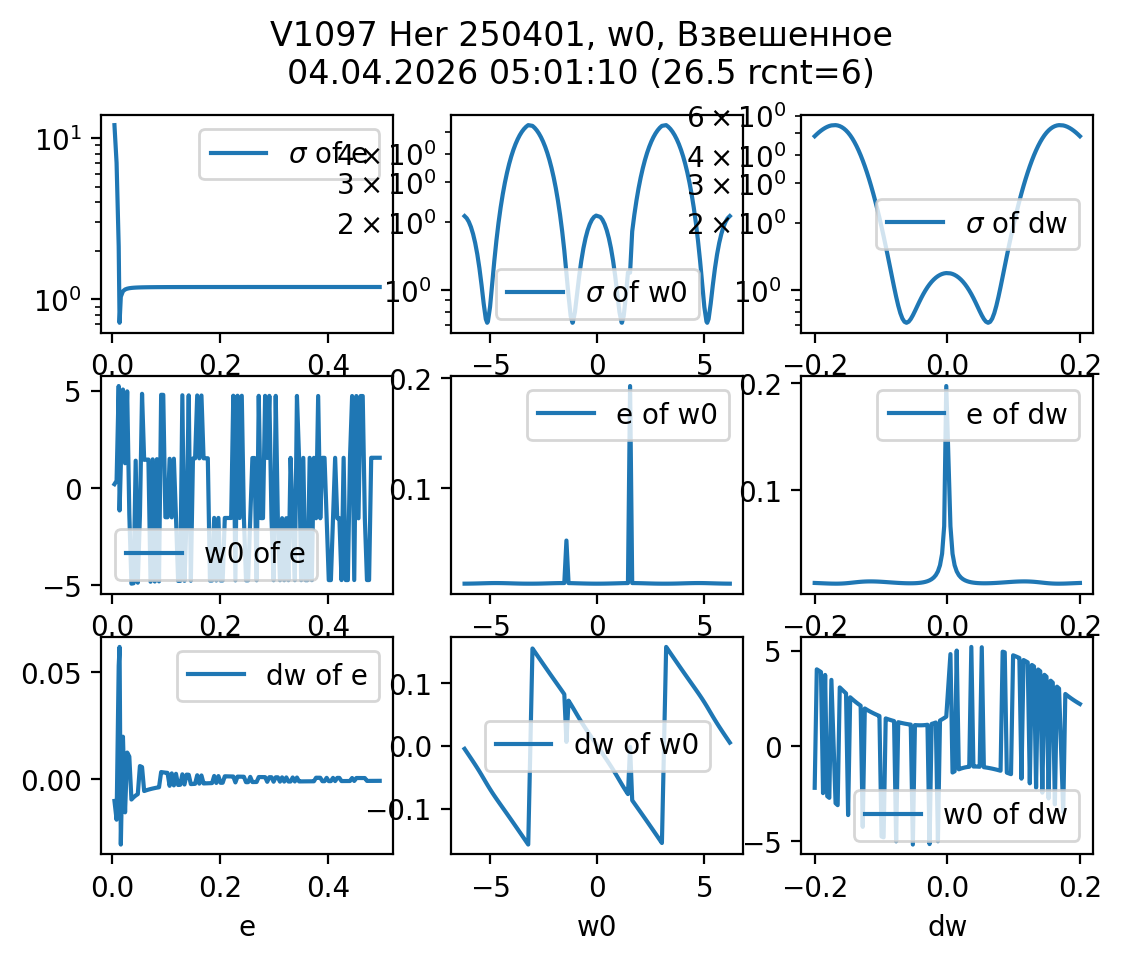

In [45]:
fig, ax, minres_a = bound_plot(res, bounds, log=True)
if minres_a.cost < res.cost:
    print(minres_a)
    print(list(minres_a.x))

In [46]:
xm0 = norm_w0(minres_a.x)
fm0 = ecw_cost(xm0)
print(list(xm0), fm0, fm0 <= ecw_cost(minres_a.x))
fm, xm = micro_opt(ecw_cost, fm0, xm0, x_w0, steps=1000)
print(list(xm), fm, fm <= ecw_cost(minres_a.x))
print(fm - ecw_cost(res.x))

[0.01342955146740392, 1.1527178386607562, -0.061648791558520315] 0.2559042714613619 True
[0.01342955146740392, 1.1527178386607562, -0.061648791558520315] 0.2559042714613619 True
0.0


In [47]:
xm0 = norm_w0(res.x)
fm0 = ecw_cost(xm0)
print(list(xm0), fm0, fm0 <= ecw_cost(res.x))
fm, xm = micro_opt(ecw_cost, fm0, xm0, x_w0, steps=1000)
print(list(xm), fm, fm <= ecw_cost(res.x))
print(fm - ecw_cost(res.x))

[0.01342955146740392, 1.1527178386607562, -0.061648791558520315] 0.2559042714613619 True
[0.01342955146740392, 1.1527178386607562, -0.061648791558520315] 0.2559042714613619 True
0.0


In [48]:
if "V1097 Her 250401" == data_set_id:
    if np.all(weight[0] == weight) or "w0'" == method_id[x_w0]:
        if res.x[x_w0] < 0.:
            assert np.linalg.norm(norm_w0(res.x) - norm_w0(xm)) < 1e-13
            assert np.abs(res.cost - fm) < 1e-15
            xm[x_w0] = -(xm[x_w0] + add2cos[x_w0]) - add2cos[x_w0]
            xm[x_dw] = -xm[x_dw]
            xm = norm_w0(xm)
            fm = ecw_cost(xm)
            assert np.abs(res.cost - fm) < 1e-15
            res.x = xm
            res.cost = fm

In [49]:
bounds_05_10 = bounds.copy()
bounds_05_10[:,0] = [0.5, 1.0]
x0_05_10 = x0.copy()
x0_05_10[0] = 0.75
res_05_10 = solsq(x0_05_10, bounds_05_10)
res_05_10, np.sqrt(2.*res_05_10.cost/len(res_05_10.fun))

(     message: `ftol` termination condition is satisfied.
      success: True
       status: 2
          fun: [ 6.993e+01  5.450e+01  4.199e+01  9.699e+01 -5.074e+00
                -9.424e+01  5.299e+01]
            x: [ 5.000e-01  9.459e-01 -1.253e-01]
         cost: 15373.030490661888
          jac: [[ 1.427e+02 -9.890e+01 -0.000e+00]
                [ 1.106e+02 -3.401e+01 -1.071e+02]
                ...
                [-1.695e+02  3.469e+02  7.631e+03]
                [ 1.088e+02  2.916e+01  3.346e+02]]
         grad: [ 6.242e+04  2.252e-04  7.294e-04]
   optimality: 0.0007294388269656338
  active_mask: [-1  0  0]
         nfev: 29
         njev: 29,
 66.2743874049651)

## В районе минимума

Пик: i, method_id[i]=(0, 'e') j, lowi[j], lowi[j]=(49, 0.014759817274175111, 0.014759817274175111) (0.47730135037620264, 0.7311851250764069, 0.4852099331163666)
Исправлен на resj.cost=0.48132293709474505
Пик: i, method_id[i]=(0, 'e') j, lowi[j], lowi[j]=(79, 0.01631426142040218, 0.01631426142040218) (0.5590497526796221, 1.8516984082131545, 0.56264162721704)
Исправлен на resj.cost=0.5608647490673524
Пик: i, method_id[i]=(0, 'e') j, lowi[j], lowi[j]=(89, 0.016832409469144535, 0.016832409469144535) (0.5756185299453608, 2.3251206832825955, 0.5785549366163213)
Исправлен на resj.cost=0.5771007944711676
Пик: i, method_id[i]=(0, 'e') j, lowi[j], lowi[j]=(121, 0.018490483225120074, 0.018490483225120074) (0.6121754103492416, 4.139119920529265, 0.6138920184923428)
Исправлен на resj.cost=0.6130400756558769


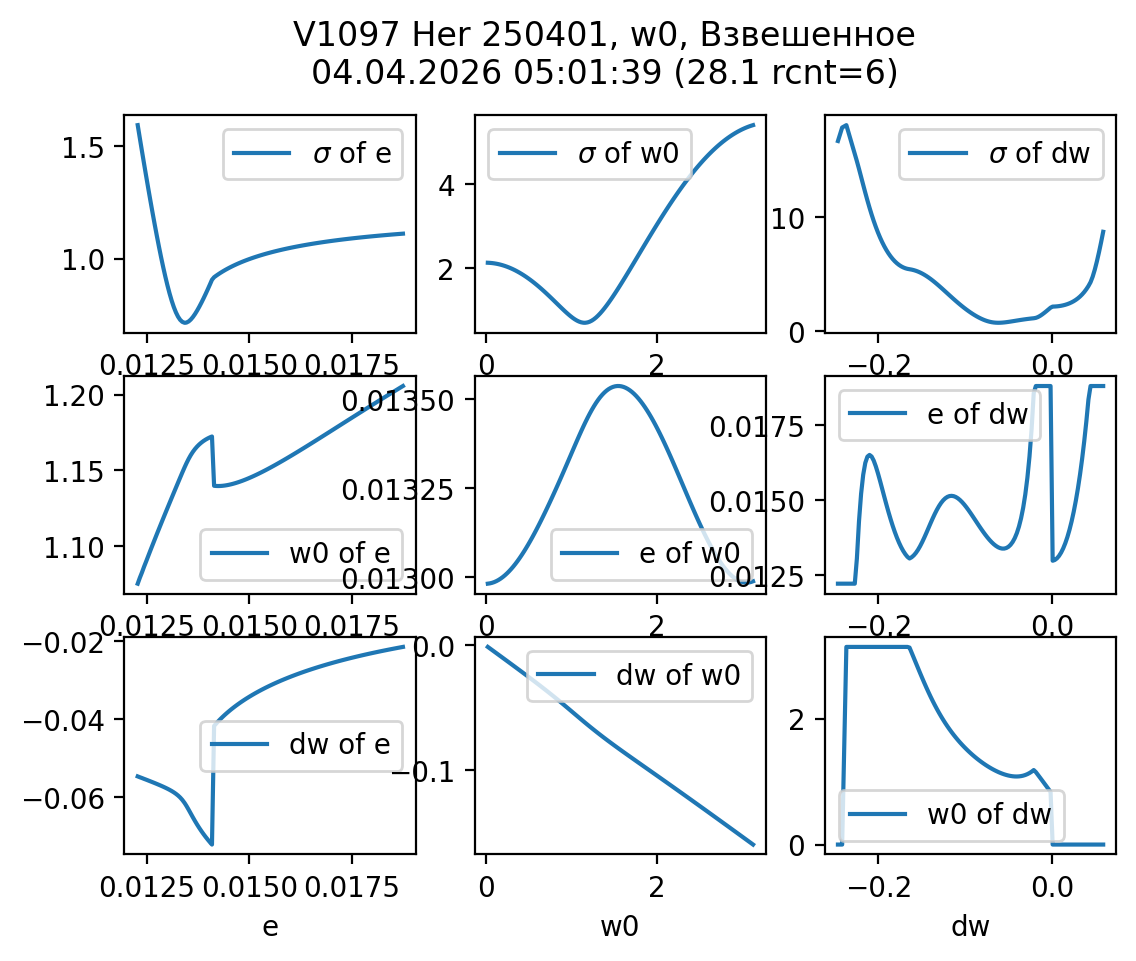

In [50]:
if "ecosw 260327" == data_set_id:
    res_bound = np.array((
            (res.x[0] - 0.7*abs(res.x[0]),
             -np.pi,
             res.x[2] - 3.0*abs(res.x[2])
            ),
            (res.x[0] + 2.0*abs(res.x[0]),
             np.pi,
             res.x[2] + 2.0*abs(res.x[2])
            )
        ))
if "V1097 Her 250401" == data_set_id:
    if not np.all(weight[0] == weight):
        res_bound = np.array((
                (res.x[0] - 0.09*abs(res.x[0]),
                 0.,
                 res.x[2] - 3.0*abs(res.x[2])
                ),
                (res.x[0] + 0.4*abs(res.x[0]),
                 np.pi,
                 res.x[2] + 2.0*abs(res.x[2])
                )
            ))
    else:
        res_bound = np.array((
                (res.x[0] - 0.2*abs(res.x[0]),
                 0.,
                 res.x[2] - 3.0*abs(res.x[2])
                ),
                (res.x[0] + 1.*abs(res.x[0]),
                 np.pi,
                 res.x[2] + 2.0*abs(res.x[2])
                )
            ))
    if "w0'" == method_id[x_w0]:
        if res.x[x_w0_s] > 0.5*np.pi:
            res_bound[:, x_w0_s] = res_bound[:, x_w0_s] + 0.5*np.pi
        else:
            res_bound[:, x_w0_s] = res_bound[:, x_w0_s] - 0.5*np.pi
fig, ax, minres_b = bound_plot(res, res_bound, log=False)
if minres_b.cost < res.cost and minres_b.cost < minres_a.cost:
    print(minres_b)
    print(list(minres_b.x))

In [51]:
xm0 = norm_w0(minres_b.x)
fm0 = ecw_cost(xm0)
print(list(xm0), fm0, fm0 <= ecw_cost(minres_b.x))
fm, xm = micro_opt(ecw_cost, fm0, xm0, x_w0, steps=1000)
print(list(xm), fm, fm <= ecw_cost(minres_b.x))
print(fm - ecw_cost(res.x))

[0.01342955146740392, 1.1527178386607562, -0.061648791558520315] 0.2559042714613619 True
[0.01342955146740392, 1.1527178386607562, -0.061648791558520315] 0.2559042714613619 True
0.0


In [52]:
print(res)
print(list(res.x))

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [-8.476e-02  1.841e-01  4.100e-01 -3.196e-01  4.285e-01
               -1.050e-01  7.653e-02]
           x: [ 1.343e-02  1.153e+00 -6.165e-02]
        cost: 0.2559042714613619
         jac: [[ 9.903e+01 -2.993e+00 -0.000e+00]
               [ 7.463e+01 -1.427e+00 -4.495e+00]
               ...
               [ 6.996e+02  1.937e+00  4.260e+01]
               [ 1.114e+02 -7.141e-01 -8.195e+00]]
        grad: [ 8.438e-13 -2.828e-13  4.186e-12]
  optimality: 4.186317958954078e-12
 active_mask: [0 0 0]
        nfev: 3
        njev: 2
[0.01342955146740392, 1.1527178386607562, -0.061648791558520315]


# Оценка ошибки методом Монте-Карло

Возмущаем `ecw` и `jdh` согласно `ecw_sigma` и `jdh_sigma`
(`eryears` и `errecow`), делим по решениям, строим графики
найденных решений и вычисляем матрицу ковариации.

In [53]:
mcrl_start = time.perf_counter()
Niter = 1000
ress = np.empty((3, Niter))
csts = np.empty(Niter)
for i in tqdm.trange(Niter):
    ecwr = np.float128(
            np.random.normal(np.float64(ecosw[:, a_ecw]),
                             np.float64(ecosw[:, a_ecw_sigma])))
    jdhr = np.float128(
            np.random.normal(np.float64(ecosw[:, a_jdh]),
                             np.float64(ecosw[:, a_jdh_sigma])))
    resr = solsq(x0, bounds, method_='lm', ecw_=ecwr, jdh_=jdhr, rcnt_=rcnt)
    ress[:, i] = resr.x
    csts[i] = resr.cost
mcrl_stop = time.perf_counter()

100%|█████████████████████████████████████████████████| 1000/1000 [00:56<00:00, 17.82it/s]


In [54]:
ress = norm_w0(ress)

"V1097 Her 250401":
- имеем два решения 1.15272 и -1.15272, разделяем выборки по
  $\omega_0 \in \left[ 0 .. \pi \right)$

In [55]:
if "V1097 Her 250401" == data_set_id:
    if "w0" == method_id[x_w0]:
        id0 = (0 <= ress[x_w0,:]) & (ress[x_w0,:] < np.pi)
    else:
        id0 = (-0.5*np.pi <= ress[x_w0_s,:]) & (ress[x_w0_s,:] < 0.5*np.pi)
    l_ress = [ress[:,~id0], ress[:,id0]]
    l_csts = [csts[~id0], csts[id0]]
    l_ress[0] = norm_w0_ex(l_ress[0], -np.pi, np.pi, 2.*np.pi)
else:
    l_ress = [ress]
    l_csts = [csts]
for r, c in zip(l_ress, l_csts):
    print(f"{r.shape[1], len(c)=}")
assert len(csts) == sum(len(c) for c in l_csts)

r.shape[1], len(c)=(335, 335)
r.shape[1], len(c)=(665, 665)


In [56]:
cov = []
err = []
for r, c in zip(l_ress, l_csts):
    cov.append(np.cov(r))
    err.append(np.sqrt(np.diag(cov[-1])))
    with np.printoptions(precision=5, suppress=True):
        print(err[-1])
    with np.printoptions(precision=2):
        print(cov[-1])
print(f"{data_set_id}, {method_id[1]}, N={ress.shape[1]}, {weight_txt}")
for i in range(3):
    print(f"{method_id[i]:4} = {res.x[i]: .5f} ± {err[-1][i]:.5f} (1𝜎, 68%)")
    if "w0'" == method_id[i]:
        print(f"{'w0':4} = {res.x[i] + add2cos[i]: .5f} ± {err[-1][i]:.5f} (1𝜎, 68%)")

[0.17812 0.30121 0.03534]
[[ 0.03 -0.03 -0.  ]
 [-0.03  0.09  0.  ]
 [-0.    0.    0.  ]]
[0.1468 0.2883 0.032 ]
[[0.02 0.02 0.  ]
 [0.02 0.08 0.  ]
 [0.   0.   0.  ]]
V1097 Her 250401, w0, N=1000, Взвешенное
e    =  0.01343 ± 0.14680 (1𝜎, 68%)
w0   =  1.15272 ± 0.28830 (1𝜎, 68%)
dw   = -0.06165 ± 0.03200 (1𝜎, 68%)


In [57]:
wcov = []
werr = []
wghs = []
for r, c in zip(l_ress, l_csts):
    # wghs.append(1./np.sqrt(c))  # [0.08559 2.47188 0.03905]
    #                             # avg - res.x  = [0.0204  0.0812  0.00121]
    #                             # avg - res.x  = [ 0.00225  0.86033 -0.01126]
    #                             # [0.17338 1.5104  0.06308]
    #                             # avg - res.x  = [ 0.07768 -0.92954  0.05967]
    #                             # [0.17033 0.25923 0.03092] [0.15706 0.29097 0.03061]
    wghs.append(1./c)           # [0.077   2.51628 0.03963]
                                # avg - res.x  = [0.01635 0.01307 0.0006 ]
                                # avg - res.x  = [ 0.00196  0.78847 -0.01385]
                                # [0.16314 1.50702 0.06426]
                                # avg - res.x  = [ 0.06683 -0.88382  0.05648]
                                # [0.16167 0.24687 0.02994] [0.14364 0.2939  0.03025]
    wcov.append(np.cov(r, aweights=wghs[-1]))
    werr.append(np.sqrt(np.diag(wcov[-1])))
    with np.printoptions(precision=5, suppress=True):
        print(werr[-1])
    with np.printoptions(precision=2):
        print(wcov[-1])
print(f"{data_set_id}, {method_id[1]}, N={l_ress[-1].shape[1]}, {weight_txt}")
for i in range(3):
    print(f"{method_id[i]:4} = {res.x[i]: .5f} ± {werr[-1][i]:.5f} (1𝜎, 68%)")
    if "w0'" == method_id[i]:
        print(f"{'w0':4} = {res.x[i] + add2cos[i]: .5f} ± {werr[-1][i]:.5f} (1𝜎, 68%)")

[0.13921 0.34784 0.0304 ]
[[ 0.02 -0.03 -0.  ]
 [-0.03  0.12  0.  ]
 [-0.    0.    0.  ]]
[0.13608 0.29929 0.02988]
[[ 0.02  0.01  0.  ]
 [ 0.01  0.09 -0.  ]
 [ 0.   -0.    0.  ]]
V1097 Her 250401, w0, N=665, Взвешенное
e    =  0.01343 ± 0.13608 (1𝜎, 68%)
w0   =  1.15272 ± 0.29929 (1𝜎, 68%)
dw   = -0.06165 ± 0.02988 (1𝜎, 68%)


```
V1097 Her 250401, w0', N=298, Взвешенное
e    =  0.01343 ± 0.19140 (1𝜎, 68%)
w0'  =  0.41808 ± 0.28465 (1𝜎, 68%)
w0   = -1.15272 ± 0.28465 (1𝜎, 68%)
dw   =  0.06165 ± 0.03498 (1𝜎, 68%)
```

```
V1097 Her 250401, w0', N=455, Без весов
e    =  0.01403 ± 0.16533 (1𝜎, 68%)
w0'  =  2.74653 ± 0.29915 (1𝜎, 68%)
w0   =  1.17573 ± 0.29915 (1𝜎, 68%)
dw   = -0.03980 ± 0.03949 (1𝜎, 68%)
```

```
V1097 Her 250401, w0, N=701, Без весов
e    =  0.01403 ± 0.21496 (1𝜎, 68%)
w0   =  1.17573 ± 0.28705 (1𝜎, 68%)
dw   = -0.03980 ± 0.03994 (1𝜎, 68%)
```

```
V1097 Her 250401, w0, N=516, Взвешенное
e    =  0.01343 ± 0.15316 (1𝜎, 68%)
w0   =  1.15272 ± 0.32953 (1𝜎, 68%)
dw   = -0.06165 ± 0.03128 (1𝜎, 68%)
```

In [58]:
for c, e, wc, we in zip(cov, err, wcov, werr):
    with np.printoptions(precision=5, suppress=True):
        print(wc-c)
        print(we-e)

[[-0.01235 -0.00008  0.00147]
 [-0.00008  0.03027  0.00159]
 [ 0.00147  0.00159 -0.00032]]
[-0.03891  0.04663 -0.00493]
[[-0.00303 -0.00154 -0.00047]
 [-0.00154  0.00646 -0.00036]
 [-0.00047 -0.00036 -0.00013]]
[-0.01072  0.01099 -0.00212]


Среднее, по результатам Монте-Карло, отличается, но
в пределах ошибок. Примерно, так и должно быть, мы же возмущаем
входные данные.

Похоже взвешивание на `1./csts` немного лучше, но...

In [59]:
with np.printoptions(precision=5, suppress=True):
    avg = np.average(l_ress[-1], axis=1)
    print(f"{'avg':12} = {avg}")
    print(f"{'avg - res.x':12} = {avg - res.x}")

avg          = [ 0.06967  1.26512 -0.05773]
avg - res.x  = [0.05624 0.1124  0.00392]


In [60]:
with np.printoptions(precision=5, suppress=True):
    avg = np.average(l_ress[-1], axis=1, weights=wghs[-1])
    print(f"{'avg':12} = {avg}")
    print(f"{'avg - res.x':12} = {avg - res.x}")

avg          = [ 0.05945  1.23738 -0.06005]
avg - res.x  = [0.04602 0.08466 0.0016 ]


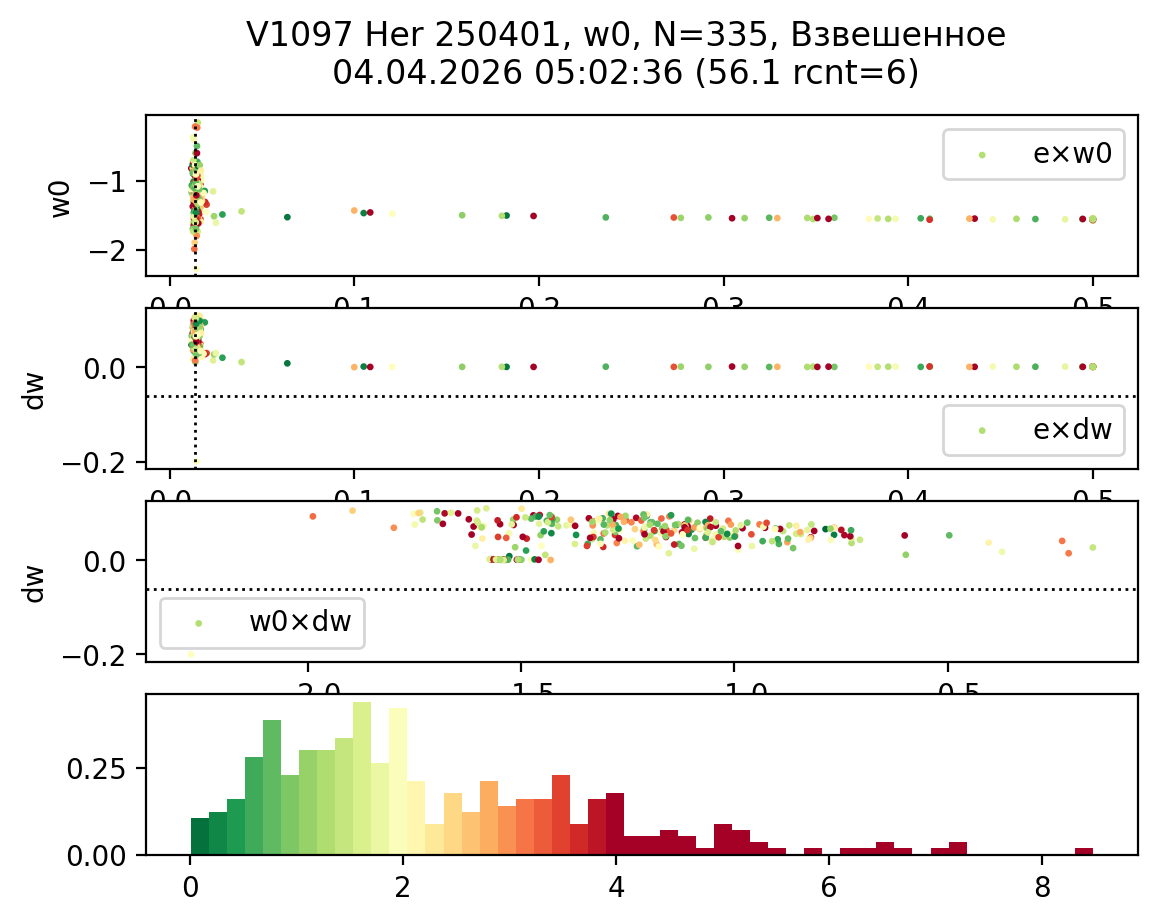

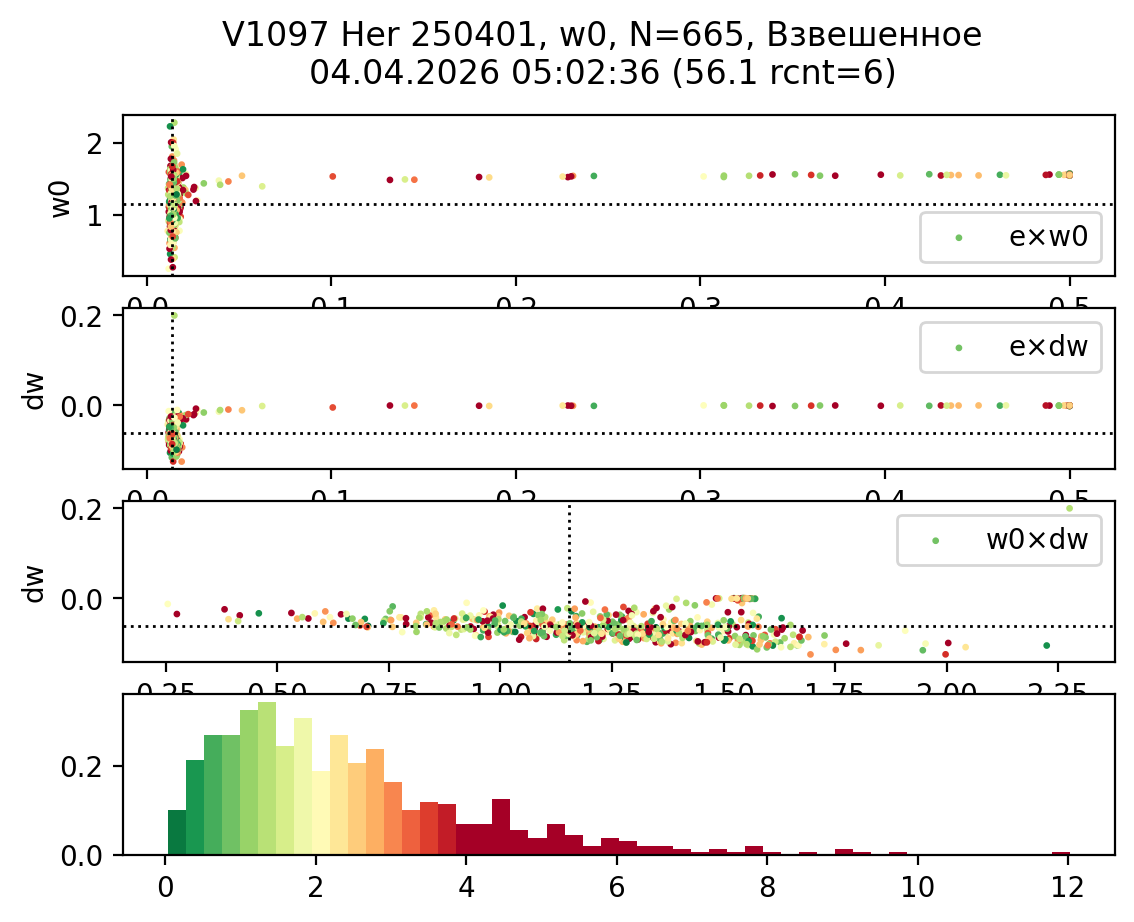

In [61]:
cm = plt.colormaps.get_cmap('RdYlGn_r')
cm_scale = 4.

for r, c in zip(l_ress, l_csts):
    fig, ax = plt.subplots(4)
    k = 0
    for i in range(2):
        for j in range(i + 1, 3):
            ax[k].scatter(r[i, :], r[j, :], 2, cm(c/cm_scale),
                       label=f"{method_id[i]}×{method_id[j]}")
            if np.min(r[i, :]) <= res.x[i] and res.x[i] <= np.max(r[i, :]):
                ax[k].axvline(res.x[i], ls=':', c='black', lw=1)
            if np.min(r[j, :]) <= res.x[j] and res.x[j] <= np.max(r[j, :]):
                ax[k].axhline(res.x[j], ls=':', c='black', lw=1)
            ax[k].legend()
            ax[k].set_xlabel(f"{method_id[i]}")
            ax[k].set_ylabel(f"{method_id[j]}")
            k += 1
    n, bins, patches = ax[3].hist(c, density=True, bins=50)
    for bc, p in zip(0.5 * (bins[:-1] + bins[1:]), patches):
        plt.setp(p, 'facecolor', cm(bc/cm_scale))

    fig.suptitle(f"{data_set_id}, {method_id[1]}, N={r.shape[1]}, {weight_txt}"
                 f"\n{time.strftime("%x %X", time.localtime())}"
                 f" ({mcrl_stop - mcrl_start:.1f} {rcnt=})")

In [62]:
for r, c in zip(l_ress, l_csts):
    print(np.min(c), np.max(c))

0.005676233652669317 8.482428806133933
0.0352336545216794 12.020179118446647


# Резюме
Явно гарантированного ответа нет.  Вроде как, видно, что при
определённых сочетаниях $\omega_0$ ($\omega_0'$) и `dw`, данные
могут быть объяснены при любом `e`. При возмущениях, согласно столбцов
ошибок входных данных, невязка может оставаться сравнительно небольшой
при любом `e`. Хотя есть сомнения в самих столбцах
ошибок входных данных.

Более вероятно:

In [63]:
print(f"{data_set_id}, {method_id[1]}, N={l_ress[-1].shape[1]}, {weight_txt}")
for i in range(3):
    print(f"{method_id[i]:4} = {res.x[i]: .5f} ± {werr[-1][i]:.5f} (1𝜎, 68%)")
    if "w0'" == method_id[i]:
        print(f"{'w0':4} = {res.x[i] + add2cos[i]: .5f} ± {werr[-1][i]:.5f} (1𝜎, 68%)")

V1097 Her 250401, w0, N=665, Взвешенное
e    =  0.01343 ± 0.13608 (1𝜎, 68%)
w0   =  1.15272 ± 0.29929 (1𝜎, 68%)
dw   = -0.06165 ± 0.02988 (1𝜎, 68%)


Но может быть и:

In [64]:
x02 = x0.copy()
bounds2 = bounds.copy()
if "ecosw 260327" == data_set_id:
    x02[x_w0] = 1.5 - add2cos[x_w0]
    bounds2[0, x_w0] = 1.3 - add2cos[x_w0]
    bounds2[1, x_w0] = 1.7 - add2cos[x_w0]
    bounds2[0, x_dw] = -0.1
if "V1097 Her 250401" == data_set_id:
    x02[x_w0] = -1.15 - add2cos[x_w0]
    bounds2[0, x_w0] = -1.4 - add2cos[x_w0]
    bounds2[1, x_w0] = -0.9 - add2cos[x_w0]
    bounds2[0, x_dw] = -0.1
res2 = solsq(x02, bounds2, rcnt_=rcnt)
res2, bounds2

(     message: `ftol` termination condition is satisfied.
      success: True
       status: 2
          fun: [-8.476e-02  1.841e-01  4.100e-01 -3.196e-01  4.285e-01
                -1.050e-01  7.653e-02]
            x: [ 1.343e-02 -1.153e+00  6.165e-02]
         cost: 0.2559042714613619
          jac: [[ 9.903e+01  2.993e+00  0.000e+00]
                [ 7.463e+01  1.427e+00  4.495e+00]
                ...
                [ 6.996e+02 -1.937e+00 -4.260e+01]
                [ 1.114e+02  7.141e-01  8.195e+00]]
         grad: [-1.302e-12 -8.858e-11  3.648e-10]
   optimality: 3.6480829468388265e-10
  active_mask: [0 0 0]
         nfev: 41
         njev: 39,
 array([[ 1.0e-07, -1.4e+00, -1.0e-01],
        [ 5.0e-01, -9.0e-01,  2.0e-01]]))

In [65]:
print(f"{data_set_id}, {method_id[1]}, N={l_ress[0].shape[1]}, {weight_txt}")
for i in range(3):
    print(f"{method_id[i]:4} = {res2.x[i]: .5f} ± {werr[0][i]:.5f} (1𝜎, 68%)")
    if "w0'" == method_id[i]:
        print(f"{'w0':4} = {res2.x[i] + add2cos[i]: .5f} ± {werr[0][i]:.5f} (1𝜎, 68%)")

V1097 Her 250401, w0, N=335, Взвешенное
e    =  0.01343 ± 0.13921 (1𝜎, 68%)
w0   = -1.15272 ± 0.34784 (1𝜎, 68%)
dw   =  0.06165 ± 0.03040 (1𝜎, 68%)


```
V1097 Her 250401, w0', N=702, Взвешенное
e    =  0.01343 ± 0.14565 (1𝜎, 68%)
w0'  =  0.41808 ± 1.50808 (1𝜎, 68%)
w0   = -1.15272 ± 1.50808 (1𝜎, 68%)
dw   =  0.06165 ± 0.03013 (1𝜎, 68%)
```

```
V1097 Her 250401, w0', N=545, Без весов
e    =  0.01403 ± 0.22656 (1𝜎, 68%)
w0'  =  0.39506 ± 0.25672 (1𝜎, 68%)
w0   = -1.17573 ± 0.25672 (1𝜎, 68%)
dw   =  0.03980 ± 0.04157 (1𝜎, 68%)
```

```
V1097 Her 250401, w0, N=299, Без весов
e    =  0.01403 ± 0.20657 (1𝜎, 68%)
w0   = -1.17573 ± 0.32936 (1𝜎, 68%)
dw   =  0.03980 ± 0.04312 (1𝜎, 68%)
```

```
V1097 Her 250401, w0, N=484, Взвешенное
e    =  0.01343 ± 0.14720 (1𝜎, 68%)
w0   = -1.15272 ± 0.26934 (1𝜎, 68%)
dw   =  0.06165 ± 0.02989 (1𝜎, 68%)
```